In [1]:
using Dates
Dates.format(now(), "E, dd U yyyy HH:MM:SS")

"Tuesday, 14 October 2025 08:09:47"

# Distribuciones discretas de probabilidad

Vea [Distributions.jl](https://juliastats.org/Distributions.jl/stable/) para la documentación del paquete.

In [2]:
using Distributions, StatsPlots
gr()

Plots.GRBackend()

## Distribución categórica

Una distribución categórica está parametrizada por un vector $p=[p_1,p_2,\cdots,p_k]$ con $p_i \ge 0$ y $\sum_1^k p_k=1$, y se define:
$$P(X=i)=p_i, \text{ para  } i=1,2,\cdots,k$$

In [3]:
p=[.4,.2,.3,.1]
d1=Categorical(p)

Categorical{Float64, Vector{Float64}}(support=Base.OneTo(4), p=[0.4, 0.2, 0.3, 0.1])

In [4]:
params(d1)


([0.4, 0.2, 0.3, 0.1],)

In [5]:
probs(d1)

4-element Vector{Float64}:
 0.4
 0.2
 0.3
 0.1

In [6]:
ncategories(d1)

4

**pdf(X,3)** *probability density function* es P(X=3) 

In [7]:
pdf(d1,3) 

0.3

**cdf(X,3)** *cumulative density function* es $P(X \le 3)$

In [8]:
round(cdf(d1,3),digits=4) # P(X ≤ 3)

0.9

In [9]:
mean(d1)

2.1

In [10]:
var(d1)

1.09

In [11]:
std(d1)

1.044030650891055

In [12]:
using TypedTables, PrettyTables, Crayons, DataFrames

In [13]:
pdf.(d1,1:4)
t1=Table(x=1:4, P=pdf.(d1,1:4), A=cdf.(d1,1:4))
t1=DataFrame(t1)
hl = Highlighter((t1,i,j)-> (j==3) && (t1[i,j] > 0.7),crayon"blue bold")
pretty_table(t1, header_crayon=crayon"red bold", highlighters=(hl), alignment=:c )

┌───────┬─────────┬─────────┐
│   x   │    P    │    A    │
│ Int64 │ Float64 │ Float64 │
├───────┼─────────┼─────────┤
│   1   │   0.4   │   0.4   │
│   2   │   0.2   │   0.6   │
│   3   │   0.3   │   0.9   │
│   4   │   0.1   │   1.0   │
└───────┴─────────┴─────────┘


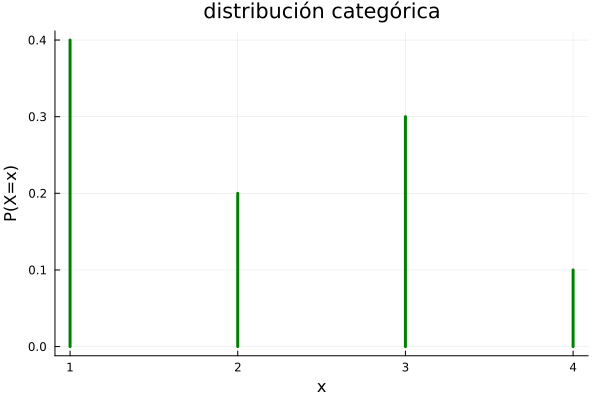

In [14]:
plot(d1,legend=false,lw=3, color=:green, title="distribución categórica",st=:sticks,xlabel="x",ylabel="P(X=x)")

# Distribución Discreta No paramétrica

Una distribución discreta no paramétrica está definida por un conjunto de valores $x_1,x_2,\cdots,x_k$ y sus probabilidades asociadas $p_1,p_2,\cdots,p_k$ con $p_i \ge 0$ y $\sum_1^k p_k=1$, y se define:
$$P(X=x_i)=p_i, \text{ para  } i=1,2,\cdots,k$$
```julia
using Distributions, Plots
```

In [3]:
xs=[-10,-1,35,40]
ps=[.4,.2,.3,.1]
d11=DiscreteNonParametric(xs,ps)

DiscreteNonParametric{Int64, Float64, Vector{Int64}, Vector{Float64}}(support=[-10, -1, 35, 40], p=[0.4, 0.2, 0.3, 0.1])

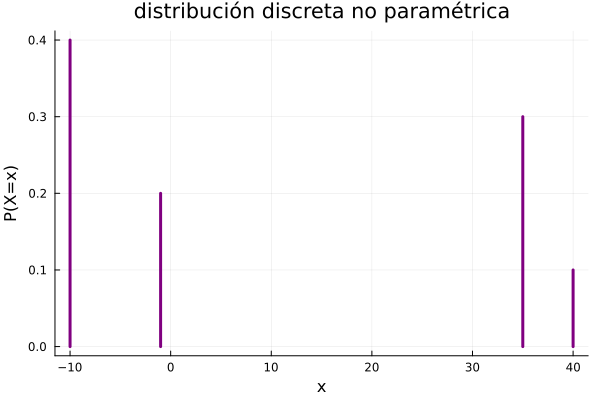

In [4]:
plot(d11,legend=false,lw=3, color=:purple, title="distribución discreta no paramétrica",st=:sticks,xlabel="x",ylabel="P(X=x)")

## Distribución binomial

### Experimento tipo
Se lanza una moneda n veces, $P(C)=p, P(S)=q, p+q=1$, X: número de caras

$$P(X=x)=\binom{n}{x}p^x q^{n-x}, \text{para } x=0,1,2,\cdots,n$$
$$E(X)=\mu_X=np, V(X)=\sigma^2_X=npq$$
$$b(n,p)$$

## Características 

1. Se realiza un experimento n veces
2. El experimento tiene dos resultados con probabilidad constante

![binomial](binomial.png)

In [15]:
d2=Binomial(12,1/6)

Binomial{Float64}(n=12, p=0.16666666666666666)

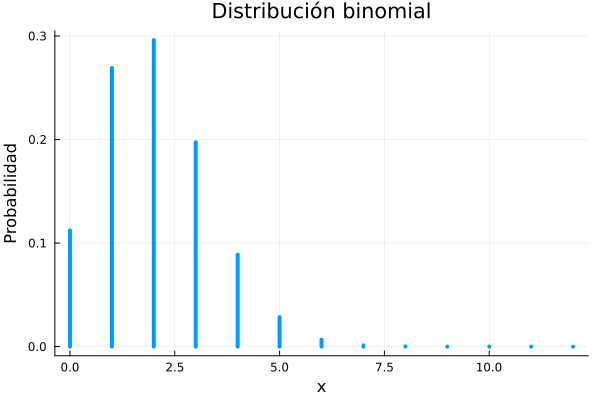

In [16]:
plot(d2,linewidth=4, legend=false, ylabel="Probabilidad", seriestype=:sticks, 
    title = "Distribución binomial", xlabel="x")

In [17]:
t2=Table(x=0:12, P=round.(pdf.(d2,0:12),digits=6), A=round.(cdf.(d2,0:12),digits=6))
t2=DataFrame(t2)
hl = Highlighter((t2,i,j)-> (j==3) && (t2[i,j] > 0.5),crayon"blue bold")
pretty_table(t2, header_crayon=crayon"red bold", highlighters=(hl), alignment=:c )

┌───────┬──────────┬──────────┐
│   x   │    P     │    A     │
│ Int64 │ Float64  │ Float64  │
├───────┼──────────┼──────────┤
│   0   │ 0.112157 │ 0.112157 │
│   1   │ 0.269176 │ 0.381333 │
│   2   │ 0.296094 │ 0.677426 │
│   3   │ 0.197396 │ 0.874822 │
│   4   │ 0.088828 │ 0.96365  │
│   5   │ 0.028425 │ 0.992075 │
│   6   │ 0.006632 │ 0.998707 │
│   7   │ 0.001137 │ 0.999844 │
│   8   │ 0.000142 │ 0.999987 │
│   9   │  1.3e-5  │ 0.999999 │
│  10   │  1.0e-6  │   1.0    │
│  11   │   0.0    │   1.0    │
│  12   │   0.0    │   1.0    │
└───────┴──────────┴──────────┘


In [18]:
mean(d2)

2.0

Salen en promedio 2 seises

In [19]:
var(d2)

1.6666666666666667

In [20]:
std(d2)

1.2909944487358056

El número de seises se aleja en promedio de la media en 1.29....

In [21]:
pdf(d2,4)   # P(X=4)

0.08882807058941525

In [22]:
cdf(d2,2)  # P(X ≤ 2)

0.6774261948990753

In [23]:
1-cdf(d2,9) # P(X ≥ 10)

7.860225488265371e-7

In [24]:
ccdf(d2,9)

7.86022548834209e-7

In [25]:
mode(d2)

2

In [26]:
minimum(d2)

0

In [27]:
maximum(d2)

12

In [28]:
extrema(d2)

(0, 12)

In [29]:
quantile(d2,0.5)

2

## Distribución de Poisson

$$P(X=x)=\frac{\lambda^x e^{-\lambda}}{x!}, \text{con  } x=0,1,2,\cdots
$$
$$E(X)=\mu_X=\lambda, V(X)=\sigma^2_X=\lambda$$
$$P(\lambda)$$
$$\text{X: número de  sucesos/tiempo(espacio)}$$
$$\text{Parámetro} \lambda >0$$

### Ejemplos de variables de Poisson

1. Número de clientes que llegan por día
2. Número de llamadas que entran por minuto
3. Número de puntos salidos por $\texttt{m}^2$ en la fabricación de tela
4. Número de bacterias por litro
5. Número de errores por página

## Ejemplo
Suponga que las llamadas entran a un conmutador a un promedio de 2 por minuto.¿Cuál es la probabilidad de que: 

1. no entren llamadas en un minuto?
2. entren más de dos llamadas por minuto?
3. entren exactamente 4 llamadas por minuto?
4. no entren llamadas en 30 segundos?
5. entren a lo más dos llamadas en minuto y medio?
6. ¿Cuál es la media y la desviación estándar del número de llamadas que entran por hora?

### Sol:

 X: número de llamadas que entran por minuto, $E(X)=2=\lambda$

$$P(X=x)=\frac{2^xe^{-2}}{x!}, x=0,1,2,\cdots$$

In [30]:
d3=Poisson(2)

Poisson{Float64}(λ=2.0)

In [31]:
params(d3)

(2.0,)

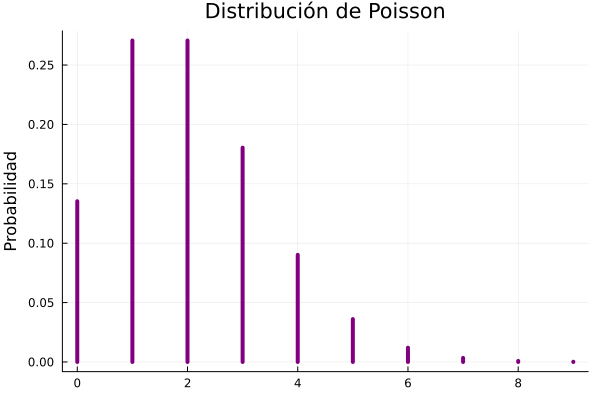

In [32]:
plot(d3,ylabel="Probabilidad",color=:purple,lw=4,legend=false, title="Distribución de Poisson", st=:sticks)

In [33]:
t3=Table(x=0:15, P=round.(pdf.(d3,0:15),digits=5), A=round.(cdf.(d3,0:15),digits=5))
t3=DataFrame(t3)
hl = Highlighter((t3,i,j)-> (j==3) && (t3[i,j] > 0.5),crayon"blue bold")
pretty_table(t3, header_crayon=crayon"red bold", highlighters=(hl), alignment=:c )

┌───────┬─────────┬─────────┐
│   x   │    P    │    A    │
│ Int64 │ Float64 │ Float64 │
├───────┼─────────┼─────────┤
│   0   │ 0.13534 │ 0.13534 │
│   1   │ 0.27067 │ 0.40601 │
│   2   │ 0.27067 │ 0.67668 │
│   3   │ 0.18045 │ 0.85712 │
│   4   │ 0.09022 │ 0.94735 │
│   5   │ 0.03609 │ 0.98344 │
│   6   │ 0.01203 │ 0.99547 │
│   7   │ 0.00344 │ 0.9989  │
│   8   │ 0.00086 │ 0.99976 │
│   9   │ 0.00019 │ 0.99995 │
│  10   │ 4.0e-5  │ 0.99999 │
│  11   │ 1.0e-5  │   1.0   │
│  12   │   0.0   │   1.0   │
│  13   │   0.0   │   1.0   │
│  14   │   0.0   │   1.0   │
│  15   │   0.0   │   1.0   │
└───────┴─────────┴─────────┘


In [34]:
hasfinitesupport(d3)

false

¿Cuál es la probabilidad de que no entren llamadas en 1 minuto?

$$P(X=0)=\frac{2^0e^{-2}}{0!}=0.1121....$$

In [35]:
pdf(d2,0)

0.11215665478461512

¿Cuál es la probabilidad de que entren más de dos llamadas por minuto?
$$P(X \ge 3)=1-P(X \le 2)=1-(P(X=0)+P(X=1)+P(X=2))=0.3233...$$

In [36]:
1-cdf(d3,2)

0.3233235838169365

In [37]:
ccdf(d3,2)

0.3233235838169365

entren exactamente 4 llamadas por minuto?
$P(X=4)=\displaystyle\frac{2^4 e^{-2}}{4!}=0.0902...$

In [38]:
pdf(d3,4)

0.09022352215774178

Si cambia el período de tiempo se recalcula $\lambda$ con regla de tres.

no entren llamadas en 30 segundos?
$\lambda=1$, $P(X=0)=\displaystyle\frac{1^0 e^{-1}}{0!}=0.3678...$

In [39]:
pdf(Poisson(1),0)

0.36787944117144233

entren a lo más dos llamadas en minuto y medio?
$\lambda=3$, $P(X \le 2)=1-(P(X=0)+P(X=1)+P(X=2))=0.4231....$

In [40]:
cdf(Poisson(3),2)

0.42319008112684353

¿Cuál es la media y la desviación estándar del número de llamadas que entran por hora?
$\lambda=120, E(X)=120,\sigma_X=10.9544...$

In [41]:
√(120)

10.954451150103322

## Distribución geométrica
### Experimento tipo
Se lanza una moneda hasta que salga cara, $P(C)=p, P(S)=q, p+q=1$, X : número de sellos antes de que salga la primera cara.

$$P(X=x)=pq^x, x=0,1,2,3,\cdots$$
$$ E(X)=\frac{q}{p}, V(X)=\frac{q}{p^2}$$
$$G(p)$$


## Ejemplo

El conmutador de una empresa está ocupado el 70% del tiempo. Si llamamos sucesivamente, ¿Cuál es la probabildad de que:

1. contesten por primera vez en la tercera llamada?
2. se necesiten más de dos llamadas para que contesten?
3. ¿Cuál es la media y la desviación estándar del número de ensayos hasta antes de que contesten?

In [42]:
d4=Geometric(0.3)

Geometric{Float64}(p=0.3)

In [43]:
params(d4)

(0.3,)

In [44]:
println("1.) P(X=2)= ", pdf(d4,2))

1.) P(X=2)= 0.147


In [45]:
println("2.) P(X ≥ 2)= ", ccdf(d4,1))

2.) P(X ≥ 2)= 0.49000000000000005


In [46]:
1-cdf(d4,1)

0.49

In [47]:
mean(d4)

2.3333333333333335

Se necesitan en promedio $2.\bar{3}$ llamadas hasta antes de que contesten.

In [48]:
std(d4)

2.788866755113585

El número de llamadas hasta antes de que contesten se aleja en promedio de la media en $2.78\cdots$

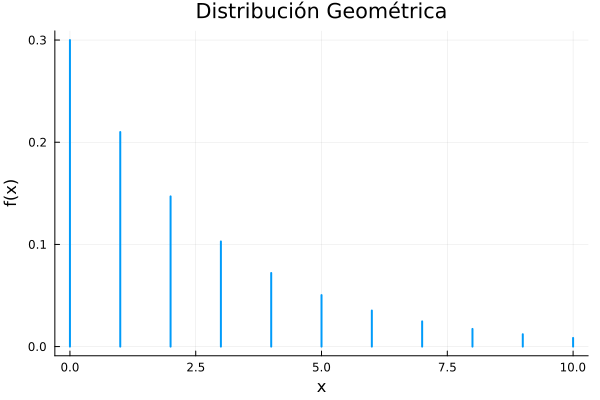

In [49]:
plot(x -> pdf(d4,x),0:10,st=:sticks,title="Distribución Geométrica",lw=2,legend=false, xlabel="x",ylabel="f(x)")

In [50]:
t4=Table(x=0:12, P=round.(pdf.(d4,0:12),digits=5), A=round.(cdf.(d4,0:12),digits=5))
t4=DataFrame(t4)
hl = Highlighter((t4,i,j)-> (j==3) && (t4[i,j] > 0.5),crayon"blue bold")
pretty_table(t4, header_crayon=crayon"red bold", highlighters=(hl), alignment=:c )

┌───────┬─────────┬─────────┐
│   x   │    P    │    A    │
│ Int64 │ Float64 │ Float64 │
├───────┼─────────┼─────────┤
│   0   │   0.3   │   0.3   │
│   1   │  0.21   │  0.51   │
│   2   │  0.147  │  0.657  │
│   3   │ 0.1029  │ 0.7599  │
│   4   │ 0.07203 │ 0.83193 │
│   5   │ 0.05042 │ 0.88235 │
│   6   │ 0.03529 │ 0.91765 │
│   7   │ 0.02471 │ 0.94235 │
│   8   │ 0.01729 │ 0.95965 │
│   9   │ 0.01211 │ 0.97175 │
│  10   │ 0.00847 │ 0.98023 │
│  11   │ 0.00593 │ 0.98616 │
│  12   │ 0.00415 │ 0.99031 │
└───────┴─────────┴─────────┘


## Distribución hipergeométrica

Una distribution Hipergeométrica describe el número de éxitos en $n$ extracciones sin reemplazo de una población finita que contiene $s$ éxitos y $f$ fracasos. X: Número de éxitos en la muestra de $n$.

$$P(X=x)=\frac{\binom{s}{x}\binom{f}{n-x}}{\binom{s+f}{n}}, x= máx(0,n-f),\cdots, mín(n,s)$$
$$E(X)=n\frac{s}{s+f}, V(X)=n\frac{s}{s+f}\frac{f}{s+f}\frac{s+f-n}{s+f-1}$$
$$H(s,f,n)$$


## Ejemplo
Un embarque de 12 impresoras tiene 4 con defectos, se extraen 5 impresoras al azar y se verifican, ¿Cuál es la probabilidad de que:

1. Todas estén buenas?
2. Haya exactamente 3 con defectos?
3. Haya a lo más dos con defectos?
4. ¿Cuál es la media y la desviación estándar del número de impresoras defectuosas en la muestra de 5?

X: Número de impresoras con defectos en la muestra de 5, $s=4, f=8, n=5$.

In [51]:
d5 = Hypergeometric(4,8,5)

Hypergeometric(ns=4, nf=8, n=5)

In [52]:
pdf(d5, 0)  # prob todas buenas

0.07070707070707069

In [53]:
pdf(d5,3)   # tres con defectos

0.1414141414141414

In [54]:
cdf(d5,2)    # a lo más dos con defectos

0.8484848484848485

In [55]:
mean(d5)

1.6666666666666667

Salen en promedio $1.\bar{6}$ impresoras con defectos en la muestra de 5.

In [56]:
var(d5)

0.7070707070707072

In [57]:
std(d5)

0.8408749651825218

El número de impresoras defectuosas en la muestra de 5 se aleja en promedio de la media en 0.8408...

In [58]:
support(d5)

0:4

In [59]:
params(d5)

(4, 8, 5)

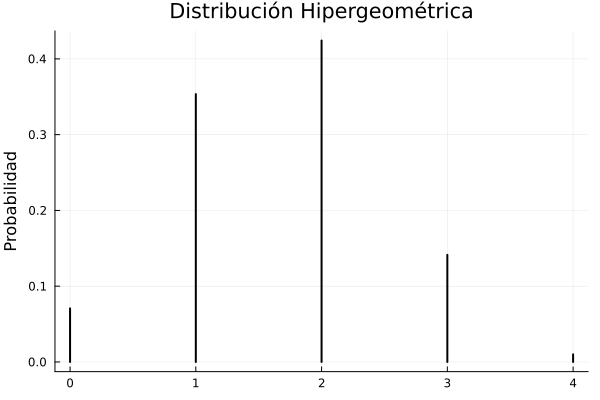

In [60]:
plot(d5, ylabel="Probabilidad", legend=false, color=:black, lw=2, title="Distribución Hipergeométrica",
    st=sticks)

In [61]:
t5=Table(x=support(d5), P=round.(pdf.(d5,support(d5)),digits=5), A=round.(cdf.(d5,support(d5)),digits=5))
t5=DataFrame(t5)
hl = Highlighter((t5,i,j)-> (j==3) && (t5[i,j] > 0.5),crayon"blue bold")
pretty_table(t5, header_crayon=crayon"red bold", highlighters=(hl), alignment=:c )

┌───────┬─────────┬─────────┐
│   x   │    P    │    A    │
│ Int64 │ Float64 │ Float64 │
├───────┼─────────┼─────────┤
│   0   │ 0.07071 │ 0.07071 │
│   1   │ 0.35354 │ 0.42424 │
│   2   │ 0.42424 │ 0.84848 │
│   3   │ 0.14141 │ 0.9899  │
│   4   │ 0.0101  │   1.0   │
└───────┴─────────┴─────────┘


## Distribución Binomial Negativa (Pascal)
### Experimento tipo
Lanzar una moneda hasta que salgan r caras, $P(C)=p, P(S)=q$ X: Número de sellos hasta antes de que salga la r-ésima cara.

$$P(X=x)=\binom{x+r-1}{x}p^rq^x, \, x=0,1,2,\dots$$
$$E(X)=\frac{rq}{p}, V(X)=\frac{rq}{p^2}$$
$$bn(r,p)$$

## Ejemplo
Una empresa petrolera ha estimado que en cierta región la probabilidad de que una perforación encuentre petróleo es de $0.2$ ¿Cuál es la probabilidad de que, para encontrar el tercer pozo productivo:
1. se necesiten 7 perforaciones?
2. se necesiten al menos 5 perforaciones?
3. ¿Cuál es la media y la desviación estándar del número de perforaciones hasta antes de encontrar el tercer pozo productivo?

$r=3, p=0.2$, X: Número de perforaciones no exitosas hasta antes de encontrar el tercer pozo productivo 

In [62]:
d6 = NegativeBinomial(3,.2)

NegativeBinomial{Float64}(r=3.0, p=0.2)

In [63]:
params(d6)

(3.0, 0.2)

In [64]:
println("1.) ", pdf(d6, 4))

1.) 0.04915199999999997


In [65]:
println("2.) ", 1-cdf(d6,1))# P(X>= 2)

2.) 0.9728


In [66]:
println("2.) ", ccdf(d6,1))

2.) 0.9728


In [67]:
m, d = println("3.1) ", mean(d6)), println("3.2) ", std(d6))

3.1) 12.000000000000002
3.2) 7.745966692414834


(nothing, nothing)

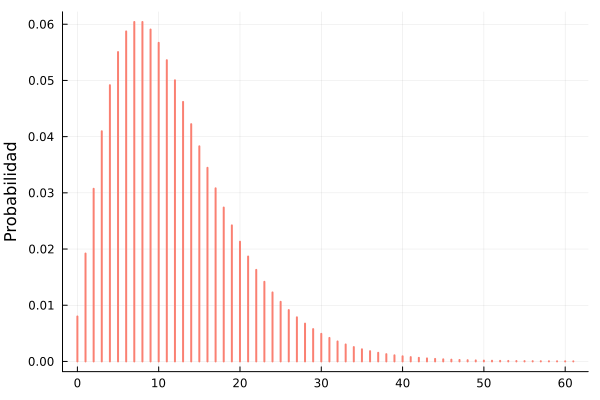

In [68]:
plot(d6, ylabel="Probabilidad", legend=false, color=:salmon, seriestype=sticks, lw=2)

In [69]:
t6=Table(x=0:25, P=round.(pdf.(d6,0:25),digits=5), A=round.(cdf.(d6,0:25),digits=5))
t6=DataFrame(t6)
hl = Highlighter((t6,i,j)-> (j==3) && (t6[i,j] > 0.5),crayon"blue bold")
pretty_table(t6, header_crayon=crayon"red bold", highlighters=(hl), alignment=:c )

┌───────┬─────────┬─────────┐
│   x   │    P    │    A    │
│ Int64 │ Float64 │ Float64 │
├───────┼─────────┼─────────┤
│   0   │  0.008  │  0.008  │
│   1   │ 0.0192  │ 0.0272  │
│   2   │ 0.03072 │ 0.05792 │
│   3   │ 0.04096 │ 0.09888 │
│   4   │ 0.04915 │ 0.14803 │
│   5   │ 0.05505 │ 0.20308 │
│   6   │ 0.05872 │ 0.2618  │
│   7   │ 0.0604  │ 0.3222  │
│   8   │ 0.0604  │ 0.3826  │
│   9   │ 0.05906 │ 0.44165 │
│  10   │ 0.05669 │ 0.49835 │
│  11   │ 0.0536  │ 0.55195 │
│  12   │ 0.05003 │ 0.60198 │
│  13   │ 0.04618 │ 0.64816 │
│  14   │ 0.04222 │ 0.69038 │
│  15   │ 0.03828 │ 0.72866 │
│  16   │ 0.03445 │ 0.76311 │
│  17   │ 0.0308  │ 0.79392 │
│  18   │ 0.02738 │ 0.8213  │
│  19   │ 0.02421 │ 0.84551 │
│  20   │ 0.02131 │ 0.86681 │
│  21   │ 0.01867 │ 0.88548 │
│  22   │ 0.01629 │ 0.90177 │
│  23   │ 0.01417 │ 0.91594 │
│  24   │ 0.01228 │ 0.92822 │
│  25   │ 0.01061 │ 0.93883 │
└───────┴─────────┴─────────┘


## Generación de números aleatorios

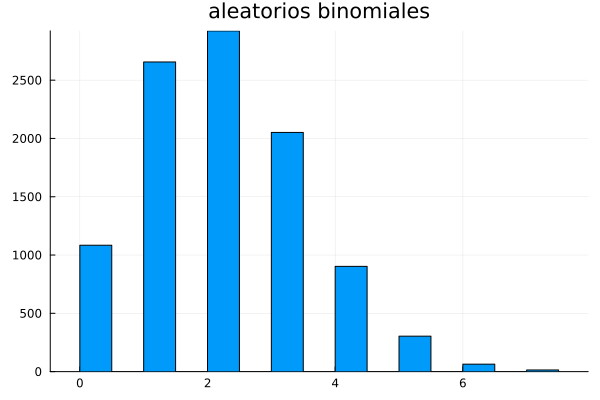

In [70]:
rbinom=rand(d2,10000); histogram(rbinom, title="aleatorios binomiales",legend=false, bins=20)

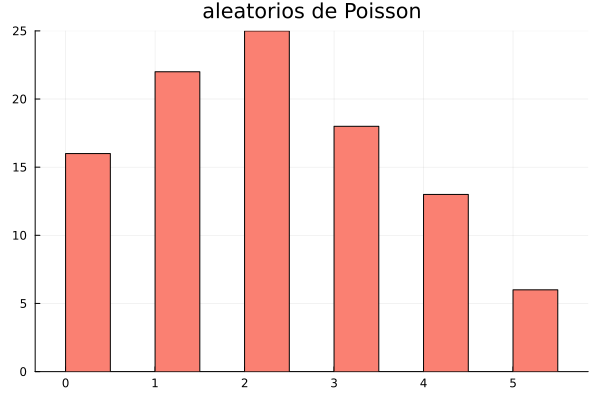

In [71]:
rpois = rand(d3,100); histogram(rpois,title="aleatorios de Poisson",legend=false, bins=20, color=:salmon)

## Diseño de presentación de gráficas

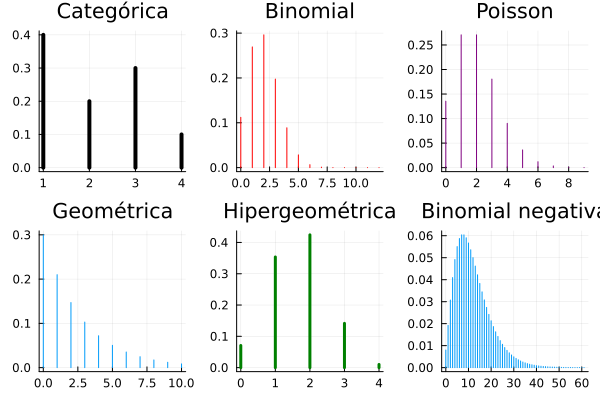

In [72]:
p1 = plot(d1, color=:black, lw=4,st=:sticks)
p2 = plot(d2, color=:red,st=:sticks)
p3 = plot(d3, color=:purple,st=:sticks)
p4 = plot(x -> pdf(d4,x),0:10,st=:sticks)
p5 = plot(d5, color=:green, lw=3, st=:sticks)
p6 = plot(d6,st=:sticks)
plot(p1,p2,p3,p4,p5,p6, layout=(2,3), legend=false, title=["Categórica" "Binomial" "Poisson" "Geométrica" "Hipergeométrica" "Binomial negativa"])

## Ejercicios

1. Un gran lote de fusibles tiene un 10% defectuosos. Se extraen al azar 4 fusibles, ¿Cuál es la probabilidad de que:
   
    a. un solo fusible esté defectuoso?
    
    b. al menos un fusible esté defectuoso?


In [73]:
bino = Binomial(4,.1)
pdf(bino, 1),1-cdf(bino,0),ccdf(bino,0)

(0.2916, 0.34389999999999965, 0.34389999999999965)



2. Una compañía de exploración petrolera va a perforar 10 pozos y cada uno de ellos tiene una probabilidad de 0.1 de producir petróleo en forma comercial. A la compañía le cuesta 10 000 dólares perforar cada pozo. Un pozo comercial saca petróleo por un valor de 500 000 dólares. 
   
    a. Calcular la ganancia promedio de la compañía en los 10 pozos.

    b. Hallar la desviación estándar de la ganancia.


In [74]:
bino2 = Binomial(10,.1)
media = mean(bino2)
ganancia(x)= 500_000*x- 10*(10_000)
gm=ganancia(media)
desv = std(bino2)
dg = 500_000*desv
gm, dg

(400000.0, 474341.64902525686)



3. Una empresa de reclutamiento encuentra que el 30% de los aspirantes para determinado puesto tiene conocimientos avanzados en programación. Calcular la probabilidad de que:

    a. el primer aspirante con conocimientos en programación sea el quinto entrevistado.
    
    b. se necesiten más de 3 entrevistas para encontrar el primer aspirante con conocimientos en programación.


In [75]:
geo= Geometric(.3)
pdf(geo, 4), 1-cdf(geo,2) # P(X>=3)

(0.07202999999999998, 0.3430000000000001)


4. En el ejercicio 3, suponga que se tienen tres puestos que necesitan conocimientos en programación. Calcular la probabilidad de que se encuentre el tercer aspirante en:

    a. la quinta entrevista.

    b. la sexta entrevista.


In [76]:
bneg = NegativeBinomial(3,.3)
pdf(bneg, 2), pdf(bneg, 3)

(0.07937999999999991, 0.09261000000000003)


5. Para determinada industria el número de accidentes es, en promedio, de tres por semana. Hallar la probabilidad de que:

    a. no se presenten accidentes en una semana.

    b. se presenten exactamente 4 accidentes en un mes.


In [77]:
pois1 =  Poisson(3)
pois2 = Poisson(12)
pdf(pois1,0), pdf(pois2,4)

(0.049787068367863944, 0.005308599473275576)


6. De una urna que contiene 4 balotas blancas y 3 rojas, se seleccionan 2 balotas alazar sin reemplazo. Calcular la probabilidad de que:

    a. se seleccione exactamente una blanca

    b. se seleccione por lo menos una blanca
    
    c. se selecione una roja







In [78]:
hip = Hypergeometric(4,3,2)
pdf(hip,1), 1-pdf(hip,0)

(0.5714285714285714, 0.8571428571428572)

In [79]:
4/7

0.5714285714285714

In [80]:
6/7

0.8571428571428571

In [81]:
hip2 = Hypergeometric(3,4,2)
pdf(hip2, 1)

0.5714285714285714

## Distribuciones discretas en Julia

### Categórica Cat(p)

$$
p=[p_1,p_2,\dots,p_k], \quad \sum_{i=1}^k p_i=1, \quad p_i \ge 0 \\
P(X=i)=p_i, \text{ para  } i=1,2,\cdots,k
$$

### Discreta No paramétrica 

$$
P(X=x_i)=p_i, \text{ para  } i=1,2,\cdots,k \\
p=[p_1,p_2,\dots,p_k] \\
\text{con } p_i \ge 0 \text{ y } \sum_{i=1}^k p_i=1
$$


### Binomial $b(n,p)$

$$
P(X = k) = {n \choose k}p^k(1-p)^{n-k},  \quad \text{ for } k = 0,1,2, \ldots, n.
$$

### Poisson $p(\lambda)$

$$
P(X = k) = \frac{\lambda^k}{k!} e^{-\lambda}, \quad \text{ for } k = 0,1,2,\ldots.
$$

### Geométrica G(p)

$$
P(X = k) = p (1 - p)^k, \quad \text{for } k = 0, 1, 2, \ldots.
$$

### Binomial negativa - Pascal bn(p,r)

$$
P(X = k) = {k + r - 1 \choose k} p^r (1 - p)^k, \quad \text{for } k = 0,1,2,\ldots.
$$

### Hipergeométrica H(s,f,n)

$$
P(X = k) = {{{s \choose k} {f \choose {n-k}}}\over {s+f \choose n}}, \quad \text{for } k = \max(0, n - f), \ldots, \min(n, s).
$$
